In [ ]:
# Configuración del entorno local (reemplaza Google Colab)
import os
import tensorflow as tf

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU detectada: {gpus[0]}')
    details = tf.config.experimental.get_device_details(gpus[0])
    print(f'   Nombre: {details.get("device_name", "N/A")}')
else:
    print('⚠️ No se detectó GPU. El entrenamiento será más lento.')

# Ruta base del proyecto
PROJECT_DIR = '/home/deeplearning/Descargas/modelo_deepCNN'
DATASET_DIR = os.path.join(PROJECT_DIR, 'Male and Female face dataset-20260505T131853Z-3-001', 'Male and Female face dataset')
RESULTADOS_DIR = os.path.join(PROJECT_DIR, 'Resultados')
print(f'📂 Proyecto: {PROJECT_DIR}')
print(f'📂 Dataset: {DATASET_DIR}')
print(f'📂 Resultados: {RESULTADOS_DIR}')


I0000 00:00:1777988396.908878   12059 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777988396.949848   12059 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777988398.063124   12059 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ GPU detectada: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   Nombre: NVIDIA RTX A5000
📂 Proyecto: /home/deeplearning/Descargas/modelo_deepCNN
📂 Dataset: /home/deeplearning/Descargas/modelo_deepCNN/Male and Female face dataset-20260505T131853Z-3-001/Male and Female face dataset
📂 Resultados: /home/deeplearning/Descargas/modelo_deepCNN/Resultados


In [ ]:
# 2. Listar archivos del proyecto
import os
print('Archivos del proyecto:', os.listdir(PROJECT_DIR))
print('\nContenido del dataset:', os.listdir(DATASET_DIR))


Archivos del proyecto: ['adaptar_notebook.py', 'verificar_cuda.py', 'Male and Female face dataset-20260505T131853Z-3-001', 'Taller_CNN_XAI.ipynb', 'Taller_CNN_XAI_colab_original.ipynb', 'Male and Female face dataset-20260505T131853Z-3-001.zip']

Contenido del dataset: ['Female Faces', 'Male Faces']


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Define la ruta donde descargaste el dataset original
input_folder = DATASET_DIR

# Define donde quieres que se cree la nueva estructura
output_folder = RESULTADOS_DIR

# Divide en: Train (80%), Validation (10%), Test (10%)
# El parámetro seed permite que la división sea reproducible
splitfolders.ratio(input_folder, output=output_folder,
                   seed=1337, ratio=(0.7, 0.15, 0.15),
                   group_prefix=None, move=False)

Copying files: 5418 files [00:01, 4235.53 files/s]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Usar los generadores con las carpetas ya divididas
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(RESULTADOS_DIR, 'train'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'  # <--- Esto asegura que siempre se busquen 3 canales
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(RESULTADOS_DIR, 'val'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'  # <--- Esto asegura que siempre se busquen 3 canales
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(RESULTADOS_DIR, 'test'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'  # <--- Esto asegura que siempre se busquen 3 canales
)

print(f"Clases encontradas: {train_generator.class_indices}")
print(f"Imágenes de entrenamiento: {train_generator.samples}")
print(f"Imágenes de validación: {validation_generator.samples}")
print(f"Imágenes de prueba: {test_generator.samples}")


Found 3791 images belonging to 2 classes.
Found 812 images belonging to 2 classes.
Found 815 images belonging to 2 classes.
Clases encontradas: {'Female Faces': 0, 'Male Faces': 1}
Imágenes de entrenamiento: 3791
Imágenes de validación: 812
Imágenes de prueba: 815


In [ ]:
import os

def print_directory_structure(path, indent='', show_files=False, max_depth=None, current_depth=0):
    """
    Imprime la estructura de carpetas de forma jerárquica

    Args:
        path: Ruta de la carpeta a escanear
        indent: Indentación para niveles anidados
        show_files: Si mostrar archivos individuales o solo carpetas
        max_depth: Profundidad máxima a mostrar (None = sin límite)
        current_depth: Profundidad actual (uso interno)
    """
    if max_depth is not None and current_depth > max_depth:
        return

    # Obtener nombre de la carpeta
    folder_name = os.path.basename(path)

    # Contar elementos
    total_items = 0
    total_folders = 0
    total_files = 0

    try:
        items = os.listdir(path)

        # Primero contar carpetas y archivos
        for item in items:
            item_path = os.path.join(path, item)
            if os.path.isdir(item_path):
                total_folders += 1
            else:
                total_files += 1

        total_items = len(items)

        # Imprimir carpeta actual
        if total_folders > 0:
            print(f"{indent}📁 {folder_name}/ ({total_files} archivos, {total_folders} subcarpetas)")
        else:
            print(f"{indent}📁 {folder_name}/ ({total_files} archivos)")

        # Procesar subcarpetas
        for item in sorted(items):
            item_path = os.path.join(path, item)
            if os.path.isdir(item_path):
                # Llamada recursiva para subcarpetas
                print_directory_structure(item_path, indent + '  ', show_files, max_depth, current_depth + 1)
            elif show_files:
                # Mostrar archivos individuales (opcional)
                print(f"{indent}  📄 {item}")

    except PermissionError:
        print(f"{indent}❌ Permiso denegado: {folder_name}")

# Uso básico
print_directory_structure(RESULTADOS_DIR)

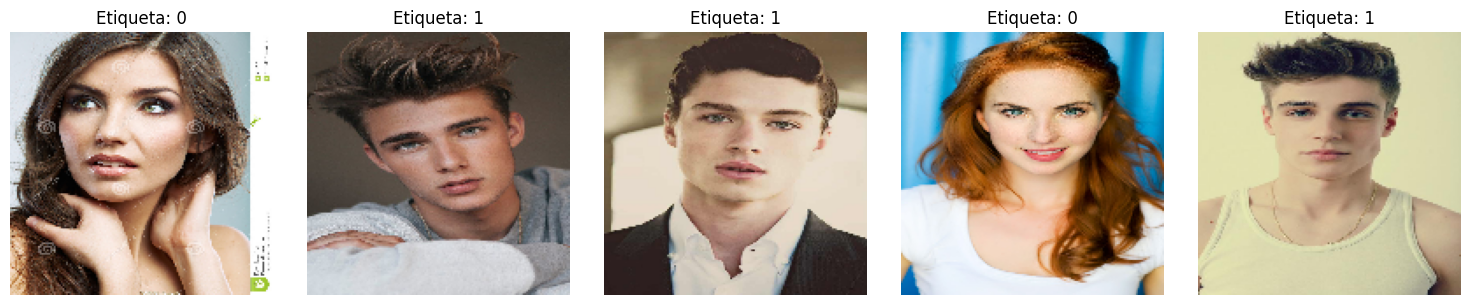

In [ ]:
import matplotlib.pyplot as plt

# Para generador de validación (cambia el nombre si usas otro)
for data_batch, labels_batch in validation_generator:
    # Crear figura con 5 subplots en una fila
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for i in range(5):
        axes[i].imshow(data_batch[i])
        axes[i].set_title(f'Etiqueta: {int(labels_batch[i])}')
        axes[i].axis('off')  # Ocultar ejes

    plt.tight_layout()
    plt.show()
    break  # Solo mostrar el primer lote

In [ ]:
import tensorflow as tf

# Verificar si hay una GPU disponible
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('⚠️ GPU no encontrada. Asegúrate de activarla en: Entorno de ejecución > Cambiar tipo de entorno de ejecución')
else:
  print(f'✅ GPU encontrada: {device_name}')

# Mostrar detalles de la GPU
!nvidia-smi -L

✅ GPU encontrada: /device:GPU:0
GPU 0: Tesla T4 (UUID: GPU-dfbbf697-283e-ec28-19c5-5c1070da859f)


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    # Añadimos Dropout para evitar que el modelo se vuelva "perezoso"
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilación
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
train_dir = os.path.join(RESULTADOS_DIR, 'train')
validation_dir = os.path.join(RESULTADOS_DIR, 'val')

# Calcular la cantidad total de imágenes en entrenamiento y validación
num_train_samples = sum([
    len(os.listdir(os.path.join(train_dir, 'Female Faces'))),
    len(os.listdir(os.path.join(train_dir, 'Male Faces')))
])

num_validation_samples = sum([
    len(os.listdir(os.path.join(validation_dir, 'Female Faces'))),
    len(os.listdir(os.path.join(validation_dir, 'Male Faces')))
])

# Definir tamaño de lote
batch_size = 20

# Calcular el número de pasos por época y pasos de validación
steps_per_epoch = num_train_samples // batch_size
validation_steps = num_validation_samples // batch_size

# Mostrar resultados
print(f"steps_per_epoch: {steps_per_epoch}")
print(f"validation_steps: {validation_steps}")

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# Configurar early stopping (opcional)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Iniciar temporizador
start_time = time.time()

# Entrenar el modelo
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    verbose=1,
    callbacks=[early_stopping]  #habilitar Early Stopping
)

# Calcular y mostrar duración del entrenamiento
total_time_minutes = (time.time() - start_time) / 60
print(f"⏱ Tiempo total de entrenamiento: {total_time_minutes:.2f} minutos")

Epoch 1/30
 51/189 ━━━━━━━━━━━━━━━━━━━━ 25:47 11s/step - accuracy: 0.5163 - loss: 0.7071

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


119/189 ━━━━━━━━━━━━━━━━━━━━ 13:33 12s/step - accuracy: 0.5811 - loss: 0.6599

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


189/189 ━━━━━━━━━━━━━━━━━━━━ 1688s 9s/step - accuracy: 0.6616 - loss: 0.5924 - val_accuracy: 0.7648 - val_loss: 0.4829
Epoch 2/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 113s 595ms/step - accuracy: 0.8095 - loss: 0.4216 - val_accuracy: 0.8498 - val_loss: 0.3205
Epoch 3/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 113s 599ms/step - accuracy: 0.8504 - loss: 0.3387 - val_accuracy: 0.8879 - val_loss: 0.2649
Epoch 4/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 111s 583ms/step - accuracy: 0.9011 - loss: 0.2416 - val_accuracy: 0.9261 - val_loss: 0.2083
Epoch 5/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 143s 595ms/step - accuracy: 0.9227 - loss: 0.1911 - val_accuracy: 0.9126 - val_loss: 0.2265
Epoch 6/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 111s 586ms/step - accuracy: 0.9507 - loss: 0.1298 - val_accuracy: 0.9680 - val_loss: 0.1100
Epoch 7/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 113s 596ms/step - accuracy: 0.9644 - loss: 0.0925 - val_accuracy: 0.9569 - val_loss: 0.1200
Epoch 8/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 111s 586ms/step - accuracy: 0.9710 - loss: 0.0805

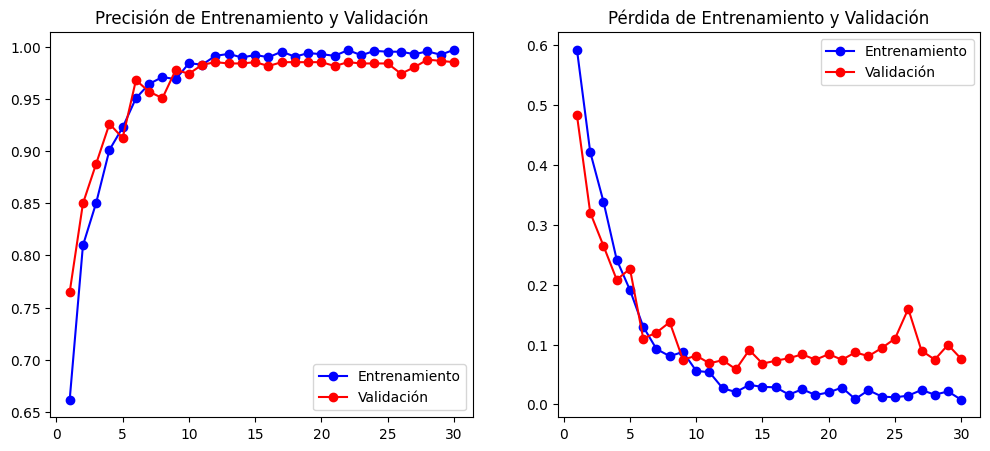

In [ ]:
import matplotlib.pyplot as plt

# Función para graficar la precisión y pérdida del entrenamiento
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Gráfico de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
    plt.plot(epochs, val_acc, 'ro-', label='Validación')
    plt.title('Precisión de Entrenamiento y Validación')
    plt.legend()

    # Gráfico de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Entrenamiento')
    plt.plot(epochs, val_loss, 'ro-', label='Validación')
    plt.title('Pérdida de Entrenamiento y Validación')
    plt.legend()

    plt.show()

# Llama a esta función después de ejecutar model.fit
if 'history' in locals():
    plot_history(history)
else:
    print('El modelo aún no ha sido entrenado. Ejecuta la celda anterior primero.')

```markdown
### Evaluación del modelo en el conjunto de Test
Una vez finalizado el entrenamiento, es fundamental evaluar el rendimiento con datos que el modelo nunca ha visto (el set de prueba).
```

In [ ]:
# Evaluar el modelo con el generador de prueba
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f'\n✅ Precisión en el conjunto de prueba (Test Accuracy): {test_acc*100:.2f}%')

25/25 ━━━━━━━━━━━━━━━━━━━━ 531s 21s/step - accuracy: 0.9725 - loss: 0.2682

✅ Precisión en el conjunto de prueba (Test Accuracy): 97.25%


In [ ]:
# Definir la ruta de guardado en tu Drive
save_path = os.path.join(PROJECT_DIR, 'modelo_caras_entrenado.h5')

# Guardar el modelo
model.save(save_path)

print(f'✅ Modelo guardado exitosamente en: {save_path}')

In [ ]:
save_path = os.path.join(PROJECT_DIR, 'modelo_caras_entrenado_keras.keras')

# Guardar el modelo
model.save(save_path)

print(f'✅ Modelo guardado exitosamente en: {save_path}')

```markdown
### Nota sobre la carga del modelo
Para volver a usarlo en el futuro sin tener que entrenar de nuevo, puedes usar:
```python
from tensorflow.keras.models import load_model
modelo_cargado = load_model('./modelo_caras_entrenado.h5')
```

<h1>Ajuste de Hiperparámetros y data augmentation<h1>

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configurar el Data Augmentation SOLO para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,       # Rota la imagen aleatoriamente hasta 15 grados
    width_shift_range=0.1,   # Desplaza la imagen horizontalmente (10% del ancho)
    height_shift_range=0.1,  # Desplaza la imagen verticalmente (10% del alto)
    zoom_range=0.1,          # Aplica un ligero zoom in/out del 10%
    horizontal_flip=True,    # Voltea la imagen como si fuera un espejo
    fill_mode='nearest'      # Si al rotar quedan espacios negros, los rellena con los píxeles más cercanos
)

# 2. Validación y Prueba NUNCA se aumentan, solo se reescalan
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Flujo de directorios (se mantiene igual, los generadores hacen el trabajo en segundo plano)
train_generator = train_datagen.flow_from_directory(
    os.path.join(RESULTADOS_DIR, 'train'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(RESULTADOS_DIR, 'val'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(RESULTADOS_DIR, 'test'),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'
)

print(f"\nResumen de carga:")
print(f"Clases encontradas: {train_generator.class_indices}")
print(f"Imágenes de entrenamiento (con aumento dinámico): {train_generator.samples}")
print(f"Imágenes de validación: {validation_generator.samples}")
print(f"Imágenes de prueba: {test_generator.samples}")

Found 3791 images belonging to 2 classes.
Found 812 images belonging to 2 classes.
Found 815 images belonging to 2 classes.

Resumen de carga:
Clases encontradas: {'Female Faces': 0, 'Male Faces': 1}
Imágenes de entrenamiento (con aumento dinámico): 3791
Imágenes de validación: 812
Imágenes de prueba: 815


In [ ]:
from tensorflow.keras import layers, models

model_2 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    # Añadimos Dropout para evitar que el modelo se vuelva "perezoso"
    layers.Dropout(0.55),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

I0000 00:00:1777988493.455302   12059 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21830 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:21:00.0, compute capability: 8.6


In [ ]:
model_2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
import os

train_dir = os.path.join(RESULTADOS_DIR, 'train')
validation_dir = os.path.join(RESULTADOS_DIR, 'val')

# Calcular la cantidad total de imágenes en entrenamiento y validación
num_train_samples = sum([
    len(os.listdir(os.path.join(train_dir, 'Female Faces'))),
    len(os.listdir(os.path.join(train_dir, 'Male Faces')))
])

num_validation_samples = sum([
    len(os.listdir(os.path.join(validation_dir, 'Female Faces'))),
    len(os.listdir(os.path.join(validation_dir, 'Male Faces')))
])

# Definir tamaño de lote
batch_size = 20

# Calcular el número de pasos por época y pasos de validación
steps_per_epoch = num_train_samples // batch_size
validation_steps = num_validation_samples // batch_size

# Mostrar resultados
print(f"steps_per_epoch: {steps_per_epoch}")
print(f"validation_steps: {validation_steps}")

steps_per_epoch: 189
validation_steps: 40


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# Configurar early stopping (opcional)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Iniciar temporizador
start_time = time.time()

# Entrenar el modelo
history_2 = model_2.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    verbose=1,
    callbacks=[early_stopping]  #habilitar Early Stopping
)

# Calcular y mostrar duración del entrenamiento
total_time_minutes = (time.time() - start_time) / 60
print(f"⏱ Tiempo total de entrenamiento: {total_time_minutes:.2f} minutos")

/home/deeplearning/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30


I0000 00:00:1777988503.917704   12059 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777988505.574126   12438 service.cc:153] XLA service 0x7f4154034ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777988505.574145   12438 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A5000, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1777988505.601400   12438 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777988505.848273   12438 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1777988505.893012   12438 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2398__.45


  1/189 ━━━━━━━━━━━━━━━━━━━━ 32:23 10s/step - accuracy: 0.5000 - loss: 0.6965

I0000 00:00:1777988514.207506   12438 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 19/189 ━━━━━━━━━━━━━━━━━━━━ 1:33 553ms/step - accuracy: 0.5026 - loss: 0.7387

I0000 00:00:1777988524.639978   12441 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2398__.45


119/189 ━━━━━━━━━━━━━━━━━━━━ 40s 581ms/step - accuracy: 0.5488 - loss: 0.6913

/home/deeplearning/miniconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


189/189 ━━━━━━━━━━━━━━━━━━━━ 94s 445ms/step - accuracy: 0.6093 - loss: 0.6485 - val_accuracy: 0.6921 - val_loss: 0.5497
Epoch 2/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 74s 389ms/step - accuracy: 0.7238 - loss: 0.5512 - val_accuracy: 0.7759 - val_loss: 0.4645
Epoch 3/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 75s 398ms/step - accuracy: 0.7552 - loss: 0.4969 - val_accuracy: 0.7919 - val_loss: 0.4463
Epoch 4/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 75s 395ms/step - accuracy: 0.7932 - loss: 0.4464 - val_accuracy: 0.8251 - val_loss: 0.3780
Epoch 5/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 76s 398ms/step - accuracy: 0.7950 - loss: 0.4297 - val_accuracy: 0.6970 - val_loss: 0.6113
Epoch 6/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 74s 392ms/step - accuracy: 0.8164 - loss: 0.4010 - val_accuracy: 0.8547 - val_loss: 0.3254
Epoch 7/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 75s 398ms/step - accuracy: 0.8396 - loss: 0.3596 - val_accuracy: 0.8251 - val_loss: 0.3528
Epoch 8/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 74s 390ms/step - accuracy: 0.8425 - loss: 0.3465 - val

In [ ]:
# Evaluar el modelo con el generador de prueba
test_loss, test_acc = model_2.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f'\n✅ Precisión en el conjunto de prueba (Test Accuracy): {test_acc*100:.2f}%')

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 467ms/step - accuracy: 0.9613 - loss: 0.1384

✅ Precisión en el conjunto de prueba (Test Accuracy): 96.13%


/home/deeplearning/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
# Definir la ruta de guardado en tu Drive
save_path = os.path.join(PROJECT_DIR, 'modelo_caras_entrenado_2.h5')

# Guardar el modelo
model_2.save(save_path)

print(f'✅ Modelo guardado exitosamente en: {save_path}')

✅ Modelo guardado exitosamente en: /home/deeplearning/Descargas/modelo_deepCNN/modelo_caras_entrenado_2.h5


In [ ]:
save_path = os.path.join(PROJECT_DIR, 'modelo_caras_entrenado_keras_2.keras')

# Guardar el modelo
model_2.save(save_path)

print(f'✅ Modelo guardado exitosamente en: {save_path}')

✅ Modelo guardado exitosamente en: /home/deeplearning/Descargas/modelo_deepCNN/modelo_caras_entrenado_keras_2.keras
